/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leadin

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-2129.726807,159.384003,-66.572601,105.272547,15329,21.042733
2,-296.574768,204.295990,11.320029,88.743342,14178,19.462710
3,-246.101562,218.857208,53.353274,84.127686,14119,19.381718
4,-204.534866,249.638596,93.477585,79.351466,14178,19.462710
5,-154.461487,389.430328,158.414722,76.006728,15043,20.650130


Returns Analysis


,1D,5D,10D
Ann. alpha,0.186,0.189,0.198
beta,-0.012,-0.002,0.019
Mean Period Wise Return Top Quantile (bps),9.842,9.474,10.084
Mean Period Wise Return Bottom Quantile (bps),-3.349,-5.767,-6.906
Mean Period Wise Spread (bps),13.191,14.951,16.567


<Figure size 640x480 with 0 Axes>

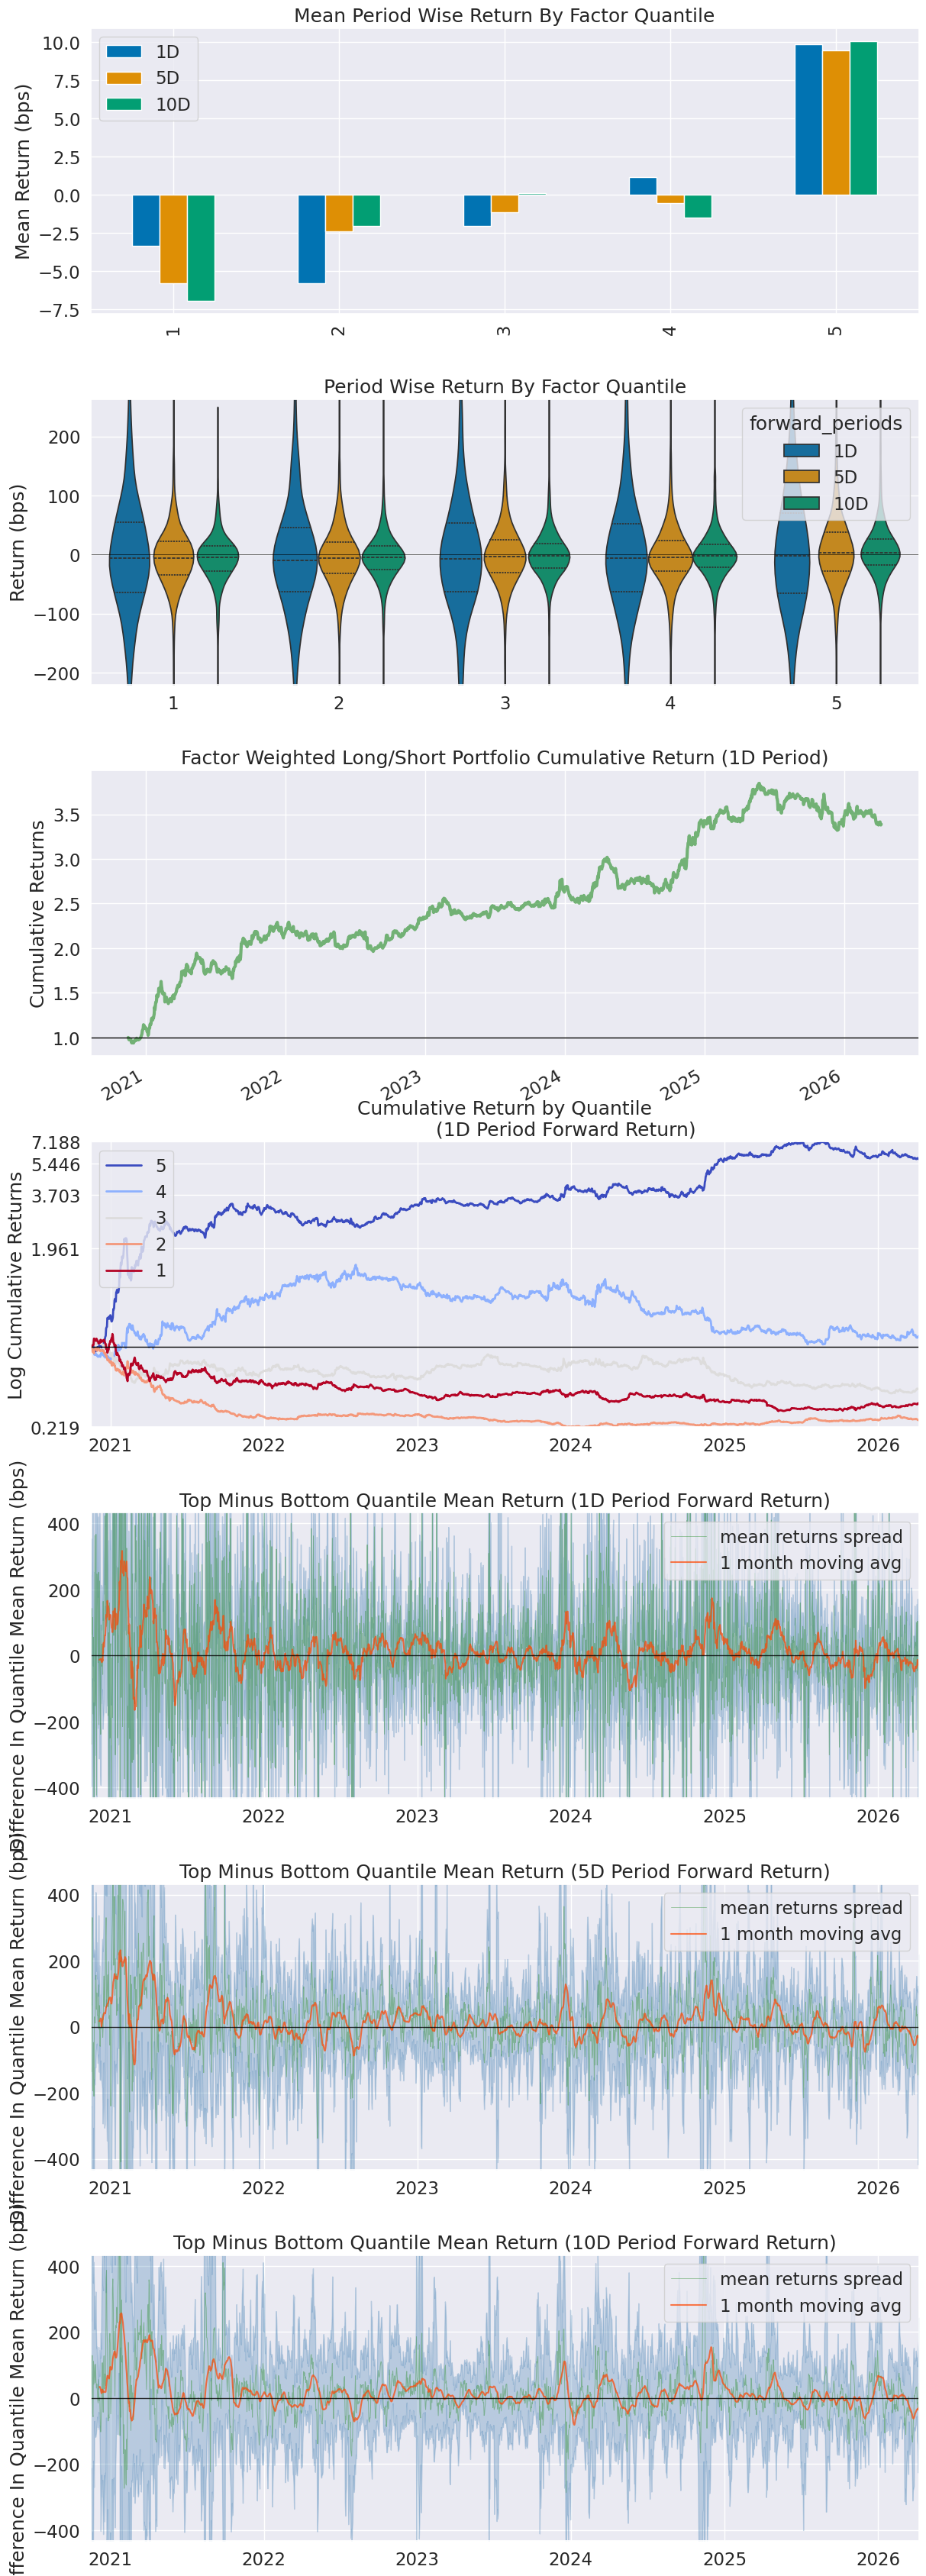

Information Analysis


,1D,5D,10D
IC Mean,0.000,0.007,0.017
IC Std.,0.199,0.202,0.198
Risk-Adjusted IC,0.002,0.034,0.084
t-stat(IC),0.071,1.515,3.725
p-value(IC),0.943,0.130,0.000
IC Skew,-0.038,-0.028,-0.098
IC Kurtosis,-0.177,-0.217,-0.141


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


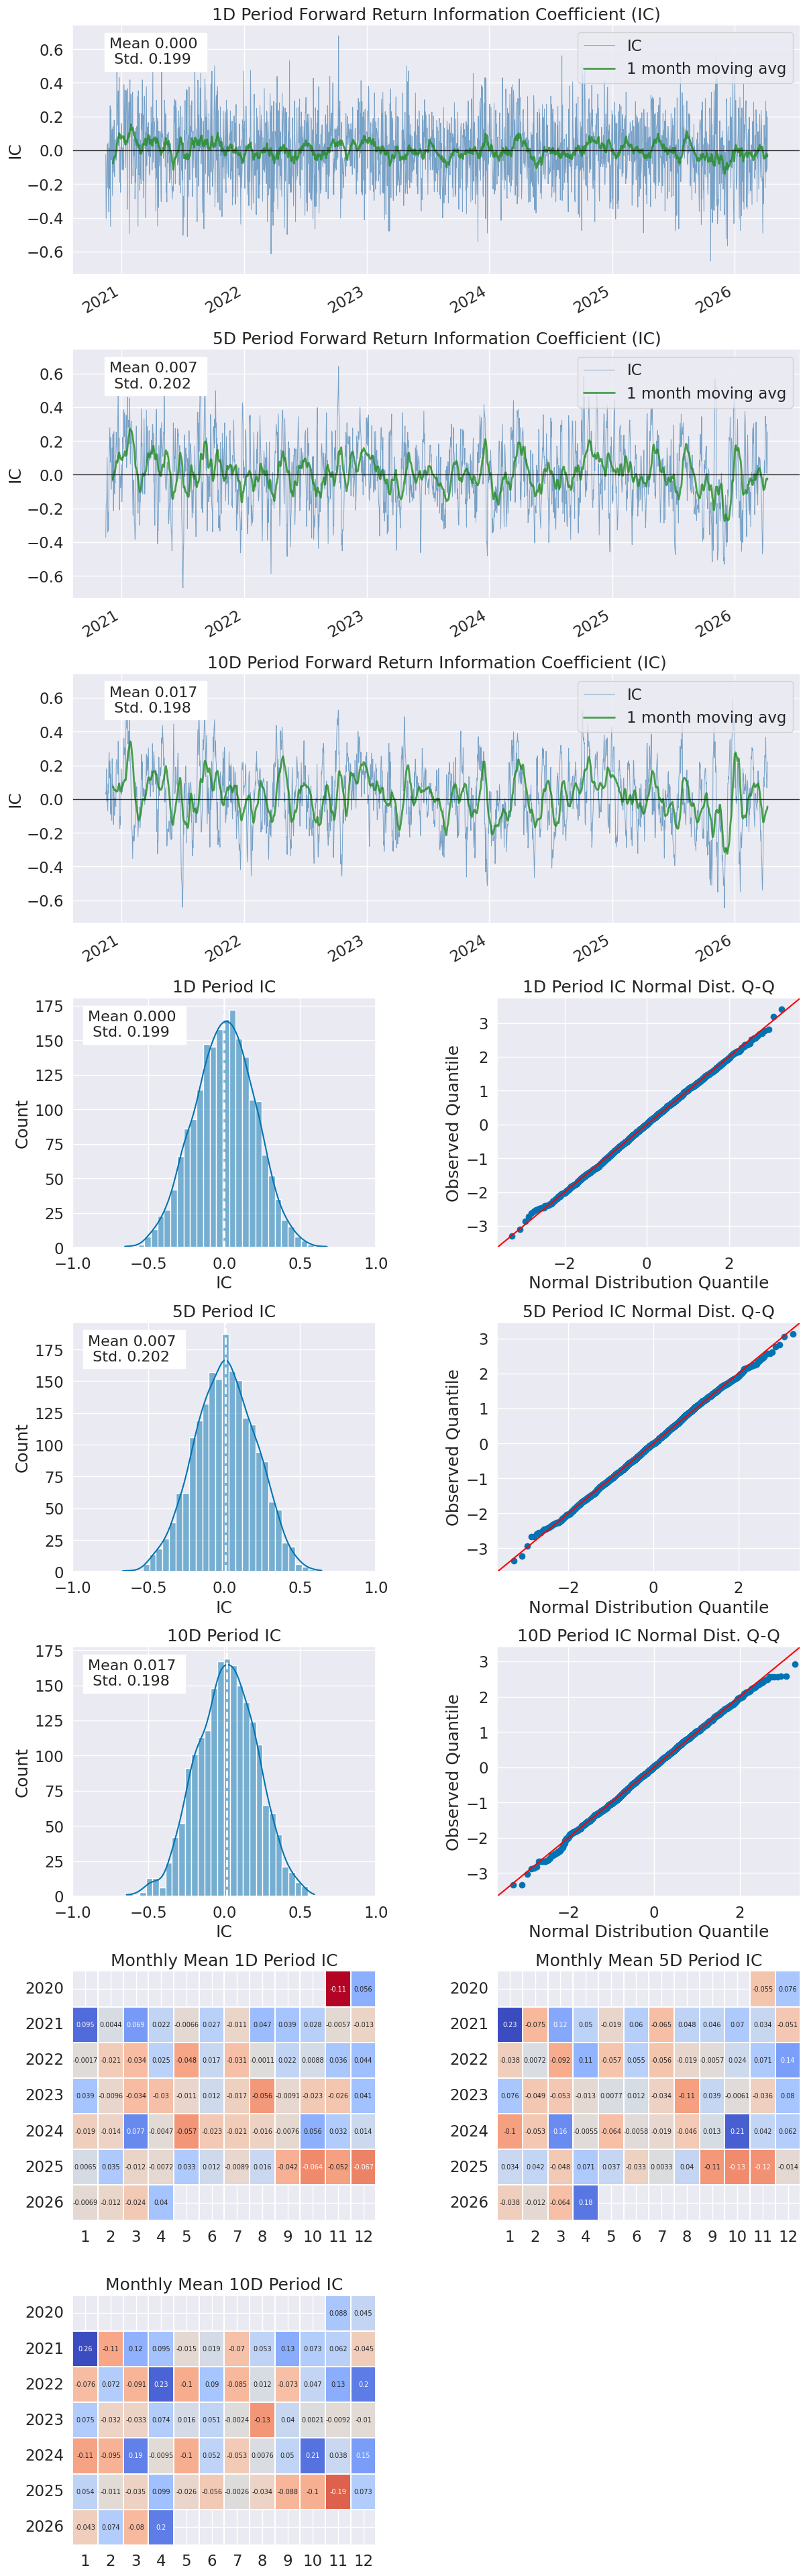

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.113,0.351,0.538
Quantile 2 Mean Turnover,0.255,0.609,0.740
Quantile 3 Mean Turnover,0.291,0.654,0.760
Quantile 4 Mean Turnover,0.260,0.627,0.743
Quantile 5 Mean Turnover,0.124,0.389,0.585


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.978,0.787,0.51


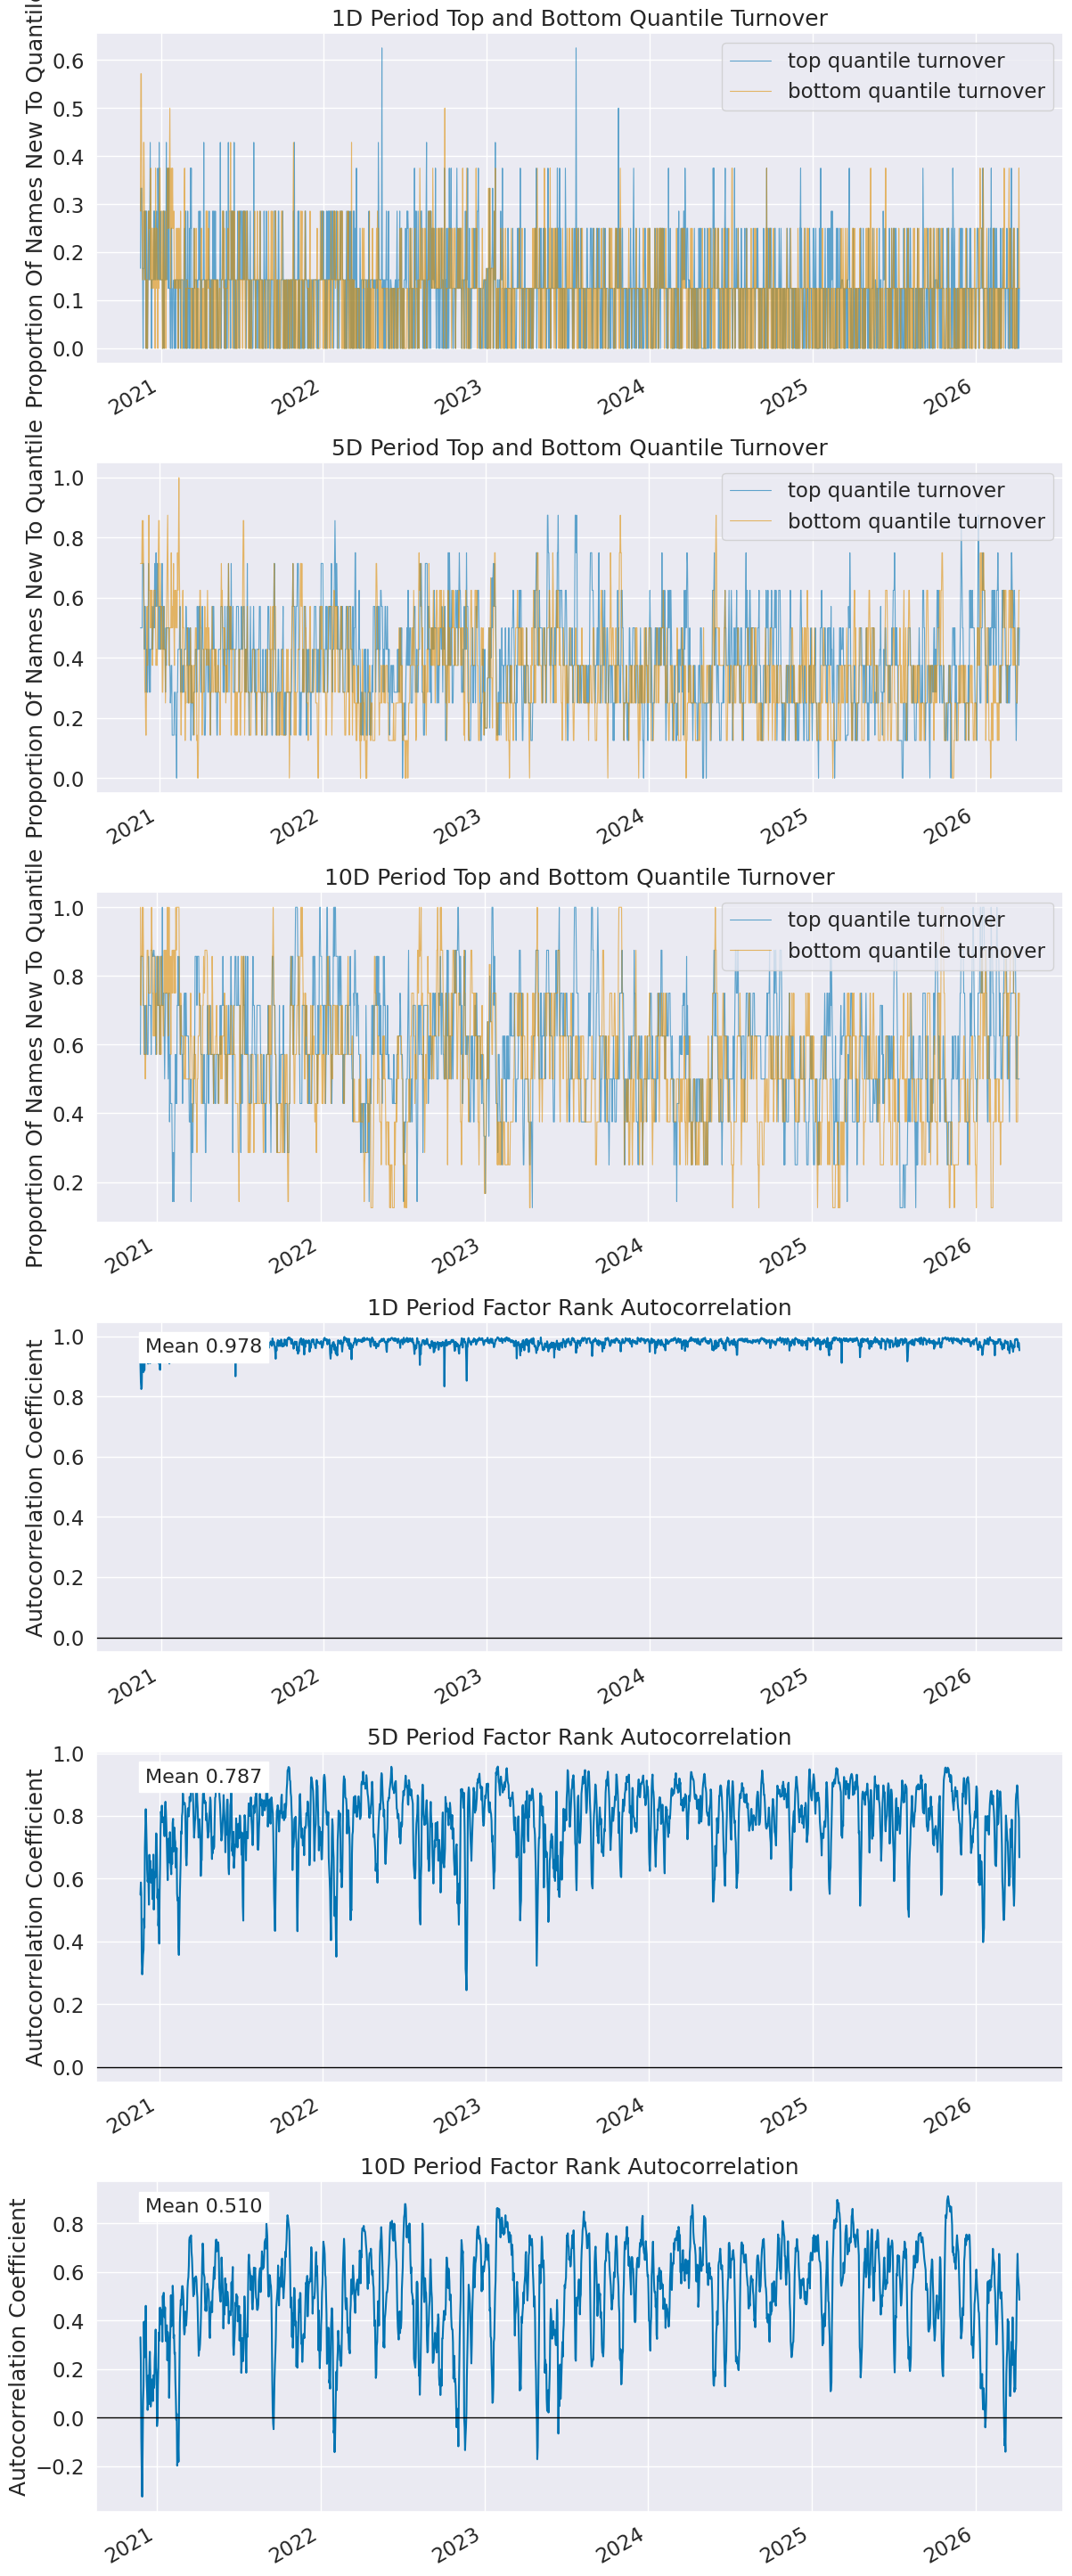

In [1]:
# AUTO-GENERATED by scripts/generate_factor_notebooks.py from
# factsheet-content/factors.yaml -- do not edit by hand. Re-run the
# generator (or the "Generate Notebooks" workflow) to refresh.
import sys
from pathlib import Path

_repo_root = Path.cwd()
while not (_repo_root / "analysis").is_dir() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
sys.path.insert(0, str(_repo_root))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Retail Flow -- portfolio retail_flow.40
portfolio = "retail_flow"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Restrict the analysis to the *dynamic* point-in-time universe rather than
# every ticker that was ever tradeable. get_historical_universe returns a
# boolean membership matrix (dates x tickers); masking the raw factor with it
# drops each asset on the days it was out of universe, so AlphaLens scores
# the factor on the universe we actually trade.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)